# Installs

In [2]:
!pip install transformers datasets evaluate pycocotools torch torchvision ipywidgets widgetsnbextension timm albumentations torchmetrics diffusers scikit-learn 'accelerate>=0.26.0'

  Using cached transformers-4.57.3-py3-none-any.whl (12.0 MB)
  Using cached datasets-4.4.1-py3-none-any.whl (511 kB)
  Using cached evaluate-0.4.6-py3-none-any.whl (84 kB)
  Using cached pycocotools-2.0.10-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (455 kB)
  Using cached torch-2.9.1-cp310-cp310-manylinux_2_28_x86_64.whl (899.8 MB)
  Using cached torchvision-0.24.1-cp310-cp310-manylinux_2_28_x86_64.whl (8.0 MB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)
  Using cached timm-1.0.22-py3-none-any.whl (2.5 MB)
  Using cached albumentations-2.0.8-py3-none-any.whl (369 kB)
  Using cached torchmetrics-1.8.2-py3-none-any.whl (983 kB)
  Using cached diffusers-0.35.2-py3-none-any.whl (4.1 MB)
  Using cached accelerate-1.12.0-py3-none-any.whl (380 kB)


# Imports

In [1]:
import os
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import ViTForImageClassification, ViTFeatureExtractor, Trainer, TrainingArguments
from torch.utils.tensorboard import SummaryWriter
from diffusers import StableDiffusionPipeline, ControlNetModel
from PIL import Image
import numpy as np
from collections import Counter
from tqdm import tqdm
import torch
import matplotlib.pyplot as plt
import albumentations as A
import numpy as np

from collections import defaultdict
from datasets import load_dataset
from datasets import Dataset
from transformers import AutoModelForObjectDetection
from transformers import AutoImageProcessor
from transformers import TrainingArguments
from transformers import Trainer
from transformers import pipeline
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torch.nn.functional import softmax
from tqdm import tqdm
from PIL import Image, ImageDraw

# Dataset

## Load dataset

In [2]:
dataset = load_dataset("ethz/food101")

In [3]:
print(dataset['train'][0])

{'image': <PIL.Image.Image image mode=RGB size=384x512 at 0x7DF999C26920>, 'label': 6}


## All classes

In [4]:
all_classes = [
    'apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare',
    'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito',
    'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake',
    'ceviche', 'cheesecake', 'cheese_plate', 'chicken_curry', 'chicken_quesadilla',
    'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder',
    'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame', 'cup_cakes',
    'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict',
    'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras',
    'french_fries', 'french_onion_soup', 'french_toast', 'fried_calamari', 'fried_rice',
    'frozen_yogurt', 'garlic_bread', 'gnocchi', 'greek_salad', 'grilled_cheese_sandwich',
    'grilled_salmon', 'guacamole', 'gyoza', 'hamburger', 'hot_and_sour_soup',
    'hot_dog', 'huevos_rancheros', 'hummus', 'ice_cream', 'lasagna',
    'lobster_bisque', 'lobster_roll_sandwich', 'macaroni_and_cheese', 'macarons', 'miso_soup',
    'mussels', 'nachos', 'omelette', 'onion_rings', 'oysters',
    'pad_thai', 'paella', 'pancakes', 'panna_cotta', 'peking_duck',
    'pho', 'pizza', 'pork_chop', 'poutine', 'prime_rib',
    'pulled_pork_sandwich', 'ramen', 'ravioli', 'red_velvet_cake', 'risotto',
    'samosa', 'sashimi', 'scallops', 'seaweed_salad', 'shrimp_and_grits',
    'spaghetti_bolognese', 'spaghetti_carbonara', 'spring_rolls', 'steak', 'strawberry_shortcake',
    'sushi', 'tacos', 'takoyaki', 'tiramisu', 'tuna_tartare',
    'waffles'
]

In [6]:
def calc_count(data, classes):
    c = [0 for i in range(len(classes))]
    for e in tqdm(data):
        c[e['label']]+=1

    return c

def draw_distr(cats, vals):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    bars = ax.bar(cats, vals, color='skyblue')
    
    ax.set_xlabel('Categories', fontsize=14)
    ax.set_ylabel('Number of Occurrences', fontsize=14)
    ax.set_title('Number of Occurrences by Category', fontsize=16)
    
    ax.set_xticklabels(cats, rotation=90, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0, height,
            f'{height}', ha='center', va='bottom', fontsize=10
        )

    plt.tight_layout()
    plt.show()

100%|████████████████████████████████████████████████████████████████████████████| 75750/75750 [01:33<00:00, 809.17it/s]
/tmp/ipykernel_754595/1153113783.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cats, rotation=90, ha='right')


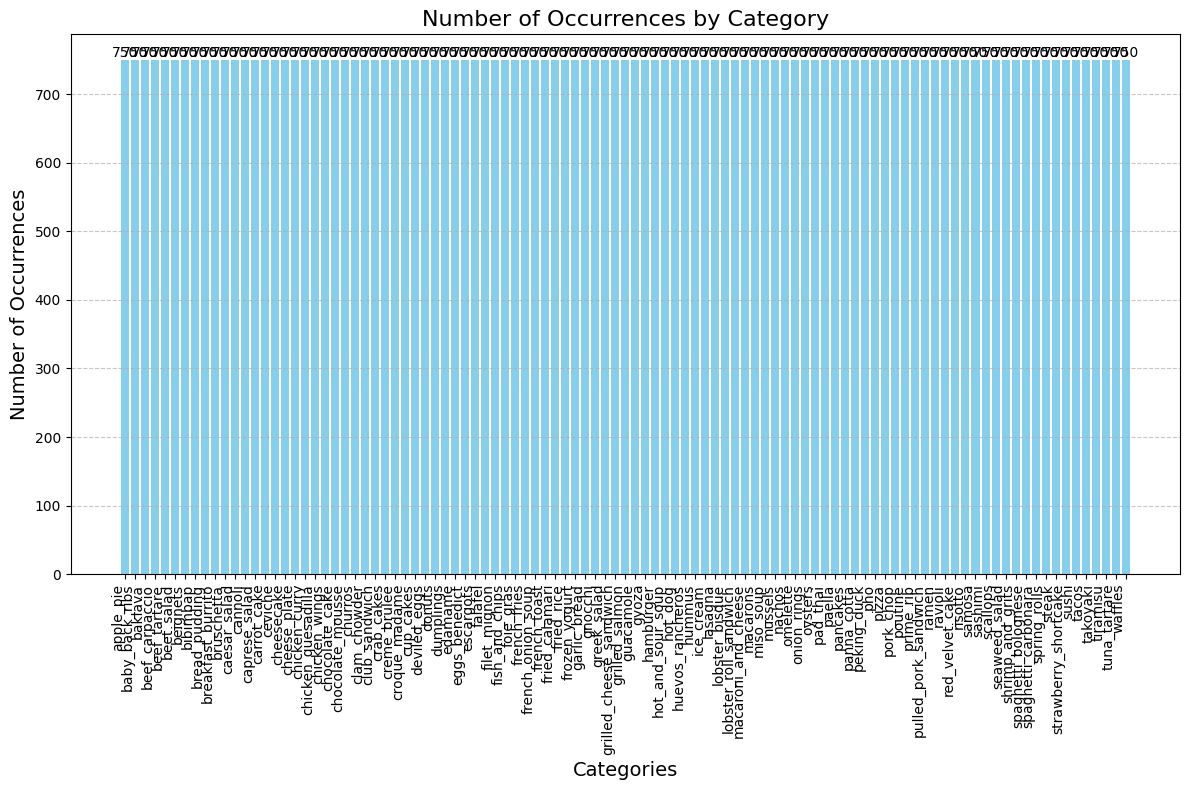

In [7]:
c = calc_count(dataset['train'], all_classes)
cats = list(all_classes)
vals = list(c)
draw_distr(cats, vals)

## Selected classes

In [8]:
selected_classes = [
    "apple_pie",
    "pizza",
    "sushi",
    "steak",
    "hamburger",
    "ice_cream",
    "chocolate_cake",
    "fried_rice",
    "spaghetti_carbonara",
    "tacos"
]

selected_classes_take_count = {
    "apple_pie": 750,
    "pizza": 750,
    "sushi": 200,
    "steak": 750,
    "hamburger": 200,
    "ice_cream": 750,
    "chocolate_cake": 750,
    "fried_rice": 750,
    "spaghetti_carbonara": 200,
    "tacos": 750
}

new2old = {new_id: all_classes.index(label) for new_id, label in enumerate(selected_classes)}
old2new = {old_id: new_id for new_id, old_id in new2old.items()}
id2label = {new_id: label for new_id, label in enumerate(selected_classes)}
label2id = {label: new_id for new_id, label in id2label.items()}

print("new2old :" + str(new2old));
print("old2new :" + str(old2new));
print("id2label :" + str(id2label));
print("label2id :" + str(label2id));

new2old :{0: 0, 1: 76, 2: 95, 3: 93, 4: 53, 5: 58, 6: 21, 7: 44, 8: 91, 9: 96}
old2new :{0: 0, 76: 1, 95: 2, 93: 3, 53: 4, 58: 5, 21: 6, 44: 7, 91: 8, 96: 9}
id2label :{0: 'apple_pie', 1: 'pizza', 2: 'sushi', 3: 'steak', 4: 'hamburger', 5: 'ice_cream', 6: 'chocolate_cake', 7: 'fried_rice', 8: 'spaghetti_carbonara', 9: 'tacos'}
label2id :{'apple_pie': 0, 'pizza': 1, 'sushi': 2, 'steak': 3, 'hamburger': 4, 'ice_cream': 5, 'chocolate_cake': 6, 'fried_rice': 7, 'spaghetti_carbonara': 8, 'tacos': 9}


In [9]:
def filter_and_limit_dataset(dataset, selected_classes, selected_classes_take_count, old2new, id2label):
    taken = [0 for i in range(len(selected_classes_take_count))]
    data = []
    for e in tqdm(dataset):
        if not (e['label'] in old2new):
            continue
        new_id = old2new[e['label']]
        if taken[new_id] >= selected_classes_take_count[id2label[new_id]]:
           continue;

        data.append({'image': e['image'], 'label': new_id})
        taken[new_id]+=1;

    return Dataset.from_list(data)

def filter_dataset(dataset, selected_classes, old2new, id2label):
    taken = [0 for i in range(len(selected_classes_take_count))]
    data = []
    for e in tqdm(dataset):
        if not (e['label'] in old2new):
            continue
        new_id = old2new[e['label']]
        
        data.append({'image': e['image'], 'label': new_id})
        taken[new_id]+=1;
    
    return Dataset.from_list(data)

# Создаем train_clear и val
train_clear = filter_and_limit_dataset(dataset['train'], selected_classes, selected_classes_take_count, old2new, id2label)
val = filter_dataset(dataset['validation'], selected_classes, old2new, id2label)

 40%|██████████████████████████████▏                                             | 30052/75750 [00:40<00:57, 797.27it/s]/home/eboiarnikov/cv-task2/venv/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|████████████████████████████████████████████████████████████████████████████| 25250/25250 [00:32<00:00, 766.94it/s]


100%|██████████████████████████████████████████████████████████████████████████████| 5850/5850 [00:25<00:00, 228.10it/s]
/tmp/ipykernel_754595/1153113783.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cats, rotation=90, ha='right')


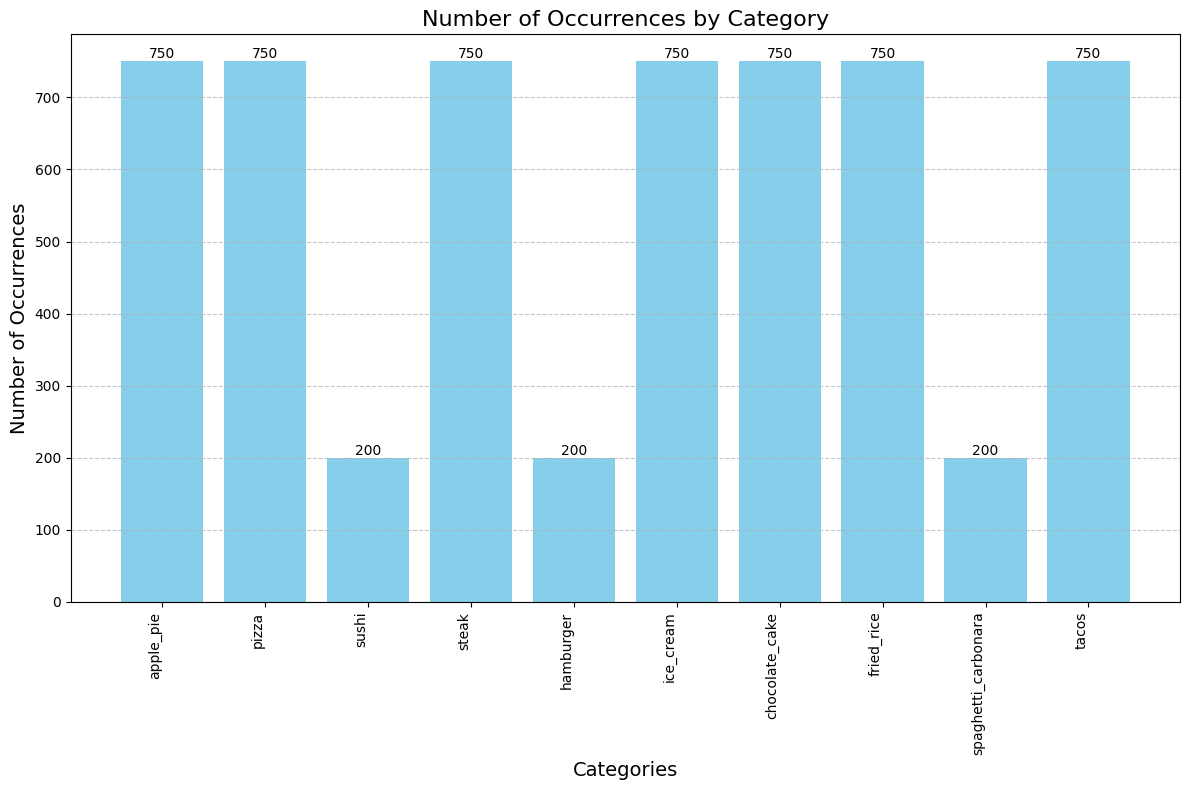

In [10]:
c = calc_count(train_clear, selected_classes)
cats = list(selected_classes)
vals = list(c)
draw_distr(cats, vals)

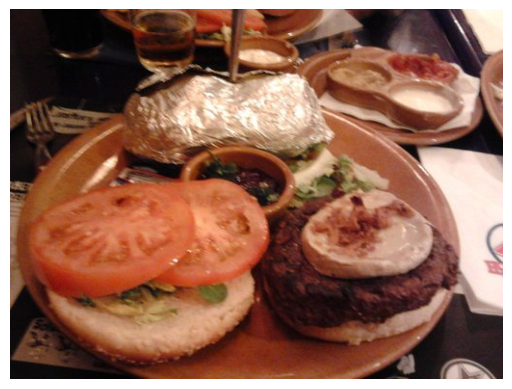

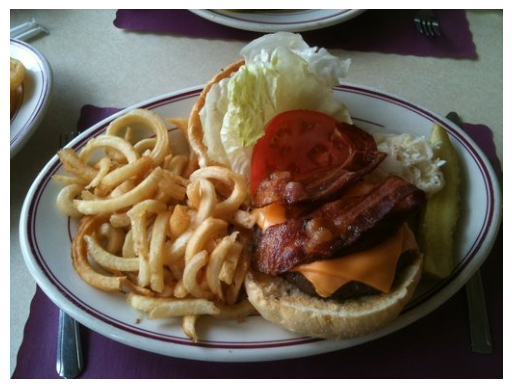

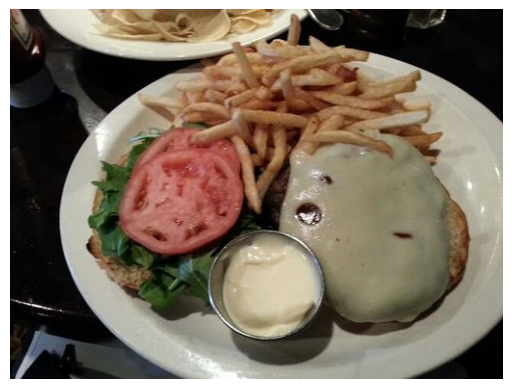

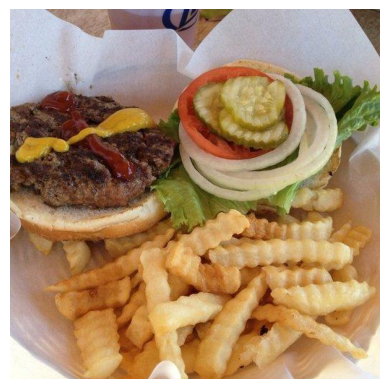

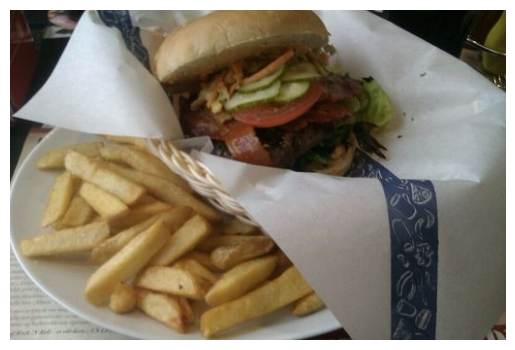

In [11]:
for img in (train_clear[:5]['image']):
    plt.imshow(img)
    plt.axis("off")
    plt.show()

## Small-size classes

In [12]:
low_classes = [label2id[label] for label, count in selected_classes_take_count.items() if count < 750]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|                                                                                           | 0/550 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|▏                                                                                  | 1/550 [00:04<40:11,  4.39s/it]

  0%|          | 0/50 [00:00<?, ?it/s]

...

100%|████████████████████████████████████████████████████████████████████████████████▋| 548/550 [38:28<00:08,  4.23s/it]

  0%|          | 0/50 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████▊| 549/550 [38:32<00:04,  4.22s/it]

  0%|          | 0/50 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████| 550/550 [38:36<00:00,  4.21s/it]


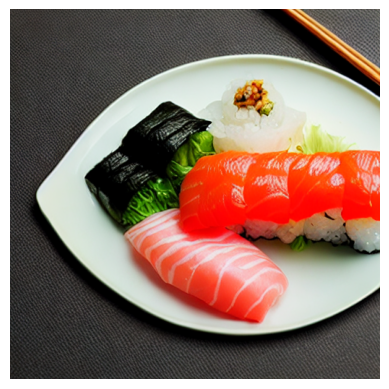

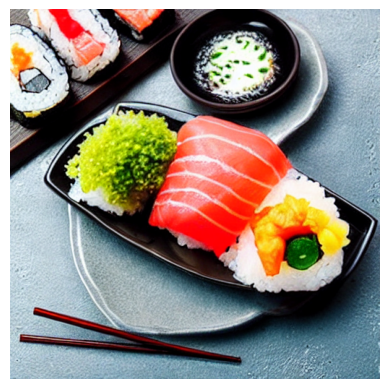

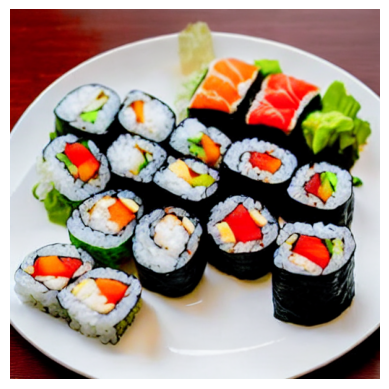

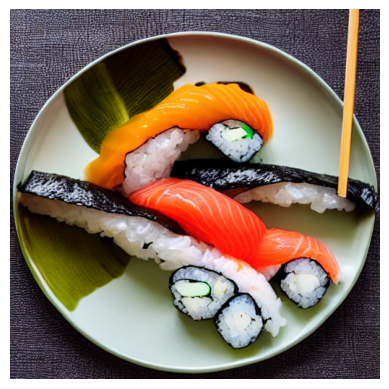

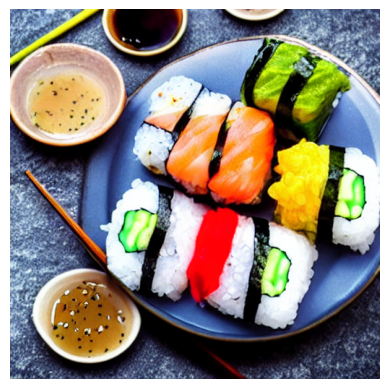

In [13]:
pipeline = StableDiffusionPipeline.from_pretrained("CompVis/stable-diffusion-v1-4")
pipeline.to("cuda")

generated_items = []
generated_images = []
for ind in low_classes:
    prompt = f"A delicious {id2label[ind]} on a plate"
    if not os.path.exists(f"generated_images/{id2label[ind]}"):
            os.makedirs(f"generated_images/{id2label[ind]}")
    for i in tqdm(range(750 - selected_classes_take_count[id2label[ind]])):
        image = pipeline(prompt).images[0]
        generated_images.append(image)
        generated_items.append({'image': image, 'label': ind})
        image.save(f"generated_images/{id2label[ind]}/{i}_.png")

for img in generated_images[:5]:
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [30]:
def merge(train, add):
    syn = []
    for e in tqdm(train):
        syn.append(e)

    for e in tqdm(add):
        syn.append(e)

    return Dataset.from_list(syn)

train_syn = merge(train_clear, generated_items)

100%|██████████████████████████████████████████████████████████████████████████| 1650/1650 [00:00<00:00, 3402459.00it/s]


100%|██████████████████████████████████████████████████████████████████████████████| 7500/7500 [00:38<00:00, 192.34it/s]
/tmp/ipykernel_754595/1153113783.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cats, rotation=90, ha='right')


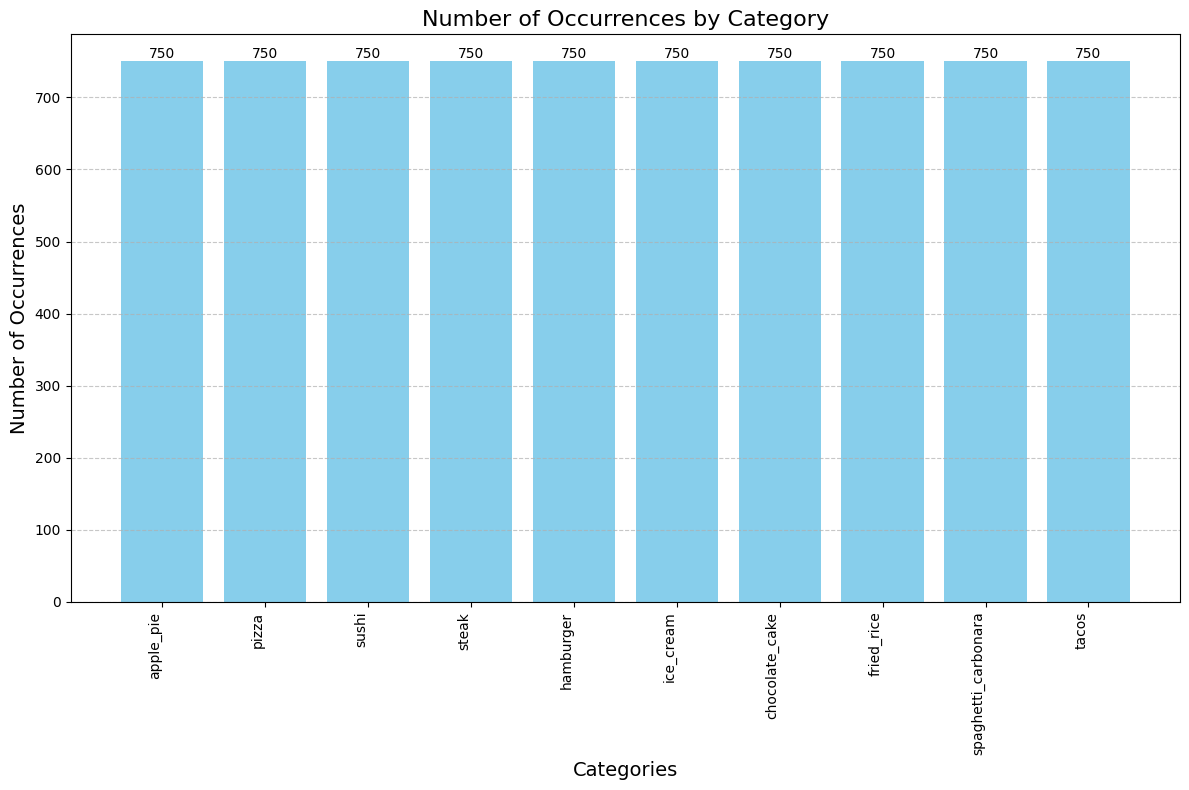

In [31]:
c = calc_count(train_syn, selected_classes)
cats = list(selected_classes)
vals = list(c)
draw_distr(cats, vals)

# Metrics

In [32]:
from sklearn.metrics import accuracy_score
from transformers import Trainer, TrainingArguments

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc}

# Model

## Transform

In [33]:
import albumentations as A
from functools import partial

def preprocess(transform, examples):
    images = [transform(image=np.array(img.convert('RGB')))['image'] for img in examples['image']]
    return {
        "pixel_values": torch.stack(images),
        "labels": torch.tensor(list(examples['label']), dtype=torch.long)
    }

train_transform = A.Compose(
    [
        A.Resize(224, 224),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.HueSaturationValue(p=0.5),
        A.Rotate(limit=10, p=0.5),
        A.GaussianBlur(p=0.5),
        A.GaussNoise(p=0.5),
        A.Normalize(
            mean=(0.5, 0.5, 0.5),
            std=(0.5, 0.5, 0.5),
        ),
        A.pytorch.ToTensorV2(),
    ],
)

train_preprocess = partial(preprocess, train_transform)

test_transform = A.Compose(
    [
        A.Resize(224, 224),
        A.Normalize(
            mean=(0.5, 0.5, 0.5),
            std=(0.5, 0.5, 0.5),
        ),
        A.pytorch.ToTensorV2(),
    ],
)

test_preprocess = partial(preprocess, test_transform)

## Load model

In [34]:
from transformers import ViTConfig, ViTForImageClassification

config = ViTConfig(
        image_size=224,
        patch_size=16,
        num_channels=3,
        num_labels=len(selected_classes),
        hidden_size=256,
        num_hidden_layers=6,
        num_attention_heads=4,
        intermediate_size=512,
        id2label=id2label,
        label2id=label2id,
)

model_clear = ViTForImageClassification(config)
model_syn = ViTForImageClassification(config)

# Train

## Arguments

In [35]:
training_args_clear = TrainingArguments(
    output_dir="./ViT_clear",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./ViT_clear/logs",
    logging_steps=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=20,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="tensorboard",

    save_steps=1000,
    save_total_limit=2,

    remove_unused_columns=False,
    no_cuda=False,
    use_cpu=False,
    dataloader_pin_memory=True,
)

training_args_syn = TrainingArguments(
    output_dir="./ViT_syn",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./ViT_syn/logs",
    logging_steps=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=20,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="tensorboard",

    save_steps=1000,
    save_total_limit=2,
    
    remove_unused_columns=False,
    no_cuda=False,
    use_cpu=False,
    dataloader_pin_memory=True,
)

In [36]:
trainer_clear = Trainer(
    model=model_clear,
    args=training_args_clear,
    train_dataset=train_clear.with_transform(train_preprocess),
    eval_dataset=val.with_transform(test_preprocess),
    compute_metrics=compute_metrics,
)

trainer_syn = Trainer(
    model=model_syn,
    args=training_args_syn,
    train_dataset=train_syn.with_transform(train_preprocess),
    eval_dataset=val.with_transform(test_preprocess),
    compute_metrics=compute_metrics,
)

## Training

In [37]:
trainer_clear.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,1.997100,2.282196,0.206000
2,1.992400,2.150241,0.234400
3,1.871600,2.164106,0.256800
4,1.868100,2.072773,0.300000
5,1.848600,1.989993,0.301200
6,1.707900,1.998862,0.311200
7,1.885400,1.889566,0.341600
8,1.881600,1.843276,0.353600
9,1.715300,1.862765,0.352800
10,1.693500,1.743721,0.378400


TrainOutput(global_step=7320, training_loss=1.7234008753885988, metrics={'train_runtime': 1278.913, 'train_samples_per_second': 91.484, 'train_steps_per_second': 5.724, 'total_flos': 3.60681211957248e+17, 'train_loss': 1.7234008753885988, 'epoch': 20.0})

In [38]:
trainer_syn.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,1.962900,2.174020,0.232400
2,1.805500,2.186908,0.260000
3,1.666500,2.021165,0.291600
4,1.510400,1.951143,0.333200
5,1.475600,1.950306,0.325600
6,1.524000,1.966752,0.348400
7,1.498600,1.915850,0.359200
8,1.402200,1.887087,0.358000
9,1.404200,1.814754,0.380000
10,1.375800,1.736811,0.402800


TrainOutput(global_step=9380, training_loss=1.450955581461697, metrics={'train_runtime': 2315.2076, 'train_samples_per_second': 64.789, 'train_steps_per_second': 4.051, 'total_flos': 4.624118102016e+17, 'train_loss': 1.450955581461697, 'epoch': 20.0})

# Evaluation

In [39]:
metrics_clear = trainer_clear.evaluate()
metrics_syn = trainer_syn.evaluate()

import pandas as pd
metrics_df = pd.DataFrame([metrics_clear, metrics_syn], index=["model_clear", "model_syn"])
metrics_df.to_csv("metrics.csv")

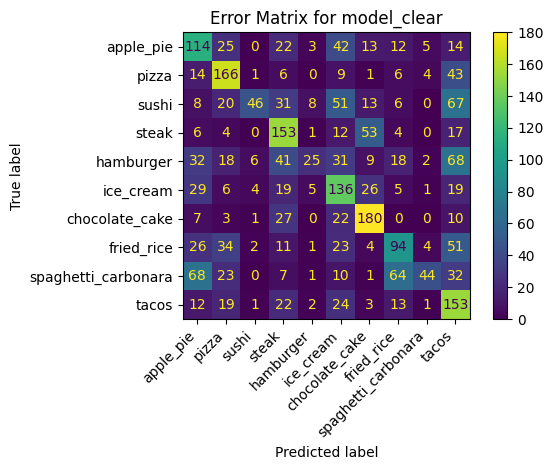

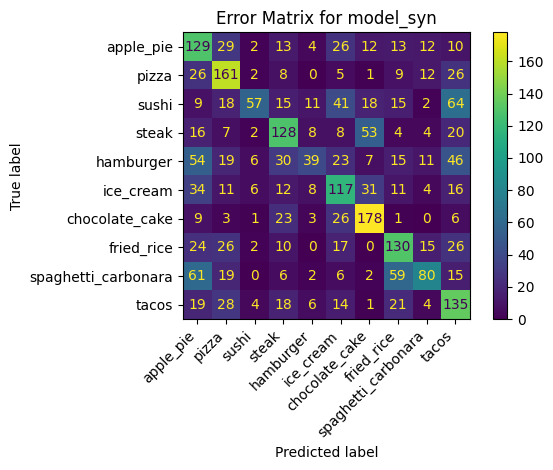

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = val['label']
y_pred_clear = trainer_clear.predict(val.with_transform(test_preprocess)).predictions.argmax(axis=1)
y_pred_syn = trainer_syn.predict(val.with_transform(test_preprocess)).predictions.argmax(axis=1)

conf_matrix_clear = confusion_matrix(y_true, y_pred_clear)
conf_matrix_syn = confusion_matrix(y_true, y_pred_syn)

disp_clear = ConfusionMatrixDisplay(conf_matrix_clear, display_labels=selected_classes)
disp_syn = ConfusionMatrixDisplay(conf_matrix_syn, display_labels=selected_classes)

disp_clear.plot()
plt.title("Error Matrix for model_clear")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("error_matrix_clear.png")
plt.show()

disp_syn.plot()
plt.title("Error Matrix for model_syn")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("error_matrix_syn.png")
plt.show()